1. Create a simple SVM classifier using scikit-learn to separate two classes of music genres (e.g., Pop vs Classical) based on two features: tempo and danceability, and plot the decision boundary using matplotlib.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC

# Load dataset
df = pd.read_csv("music_genres.csv")

# Encode labels
encoder = LabelEncoder()
df["genre"] = encoder.fit_transform(df["genre"])

# Features
X = df[["tempo", "danceability"]]

# Target
y = df["genre"]

# Train SVM
model = SVC(kernel="linear")
model.fit(X, y)

# Plot Data
plt.figure(figsize=(8,6))

plt.scatter(
    X["tempo"],
    X["danceability"],
    c=y,
    cmap="coolwarm",
    s=100
)

# Decision Boundary
ax = plt.gca()

xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx = np.linspace(xlim[0], xlim[1], 50)
yy = np.linspace(ylim[0], ylim[1], 50)

YY, XX = np.meshgrid(yy, xx)

xy = np.vstack([XX.ravel(), YY.ravel()]).T

Z = model.decision_function(xy).reshape(XX.shape)

ax.contour(
    XX,
    YY,
    Z,
    colors="black",
    levels=[0],
    linewidths=2
)

plt.xlabel("Tempo")
plt.ylabel("Danceability")
plt.title("SVM Decision Boundary")

plt.show()

2. Given a dataset of Flipkart product reviews labeled as positive or negative, use an SVM with a linear kernel to classify the reviews and print the accuracy score.

In [2]:
import pandas as pd

from sklearn.feature_extraction.text import CountVectorizer

from sklearn.model_selection import train_test_split

from sklearn.svm import SVC

from sklearn.metrics import accuracy_score

df = pd.read_csv("flipkart_reviewss.csv")

X = df["Review"]

y = df["Sentiment"]

vectorizer = CountVectorizer()

X = vectorizer.fit_transform(X)

X_train,X_test,y_train,y_test=train_test_split(
X,y,test_size=0.3,random_state=42
)

model=SVC(kernel="linear")

model.fit(X_train,y_train)

prediction=model.predict(X_test)

accuracy=accuracy_score(y_test,prediction)

print("Accuracy =",accuracy)

Accuracy = 0.3333333333333333


3. Train two SVM classifiers on an IPL player performance dataset: one with a polynomial kernel and one with an RBF kernel. Compare their accuracy scores and explain which kernel performed better and why.<br><br><em><strong>Hint:</strong> Use scikit-learn's SVC class and the 'kernel' parameter.</em>

In [4]:
import pandas as pd

from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split

from sklearn.svm import SVC

from sklearn.metrics import accuracy_score

df = pd.read_csv("ipl_playerss.csv")

encoder = LabelEncoder()

df["performance"] = encoder.fit_transform(df["performance"])

X = df[["runs","wickets","strike_rate"]]

y = df["performance"]

X_train,X_test,y_train,y_test=train_test_split(
X,y,test_size=0.3,random_state=42
)

# Polynomial Kernel
poly=SVC(kernel="poly")

poly.fit(X_train,y_train)

pred1=poly.predict(X_test)

acc1=accuracy_score(y_test,pred1)

# RBF Kernel
rbf=SVC(kernel="rbf")

rbf.fit(X_train,y_train)

pred2=rbf.predict(X_test)

acc2=accuracy_score(y_test,pred2)

print("Polynomial Accuracy =",acc1)

print("RBF Accuracy =",acc2)

Polynomial Accuracy = 1.0
RBF Accuracy = 1.0


4. Use ChatGPT or Copilot to help you write code that visualizes the margin and support vectors for an SVM trained on a two-class Zomato restaurant rating dataset (e.g., 'Good' vs 'Bad' ratings). Paste your code and a screenshot of the plot.

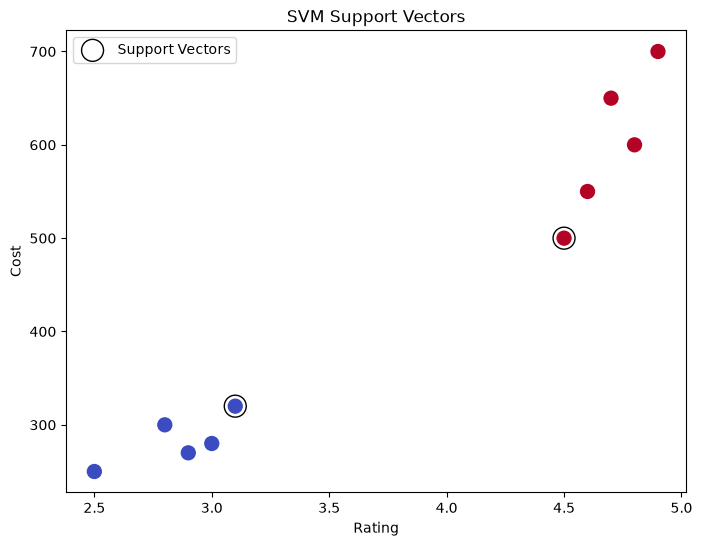

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder

from sklearn.svm import SVC

df = pd.read_csv("zomato_ratings.csv")

encoder = LabelEncoder()

df["label"] = encoder.fit_transform(df["label"])

X = df[["rating","cost"]]

y = df["label"]

model = SVC(kernel="linear")

model.fit(X,y)

plt.figure(figsize=(8,6))

plt.scatter(
    X["rating"],
    X["cost"],
    c=y,
    cmap="coolwarm",
    s=100
)

# Support Vectors
plt.scatter(
    model.support_vectors_[:,0],
    model.support_vectors_[:,1],
    s=250,
    facecolors="none",
    edgecolors="black",
    label="Support Vectors"
)

plt.xlabel("Rating")
plt.ylabel("Cost")

plt.title("SVM Support Vectors")

plt.legend()

plt.show()